In [7]:
!pip install gensim

In [8]:
# ===============================
# IMPORTING REQUIRED LIBRARIES
# ===============================

# Regular expressions for cleaning text
import re

# NLTK for tokenization
import nltk
from nltk.tokenize import word_tokenize

# Counter to count word frequencies
from collections import Counter

# Word2Vec model from gensim
from gensim.models import Word2Vec

# PCA for dimensionality reduction
from sklearn.decomposition import PCA

# Visualization libraries
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Download tokenizer resources (only needed once)
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [9]:
# ===============================
# STEP 1: TEXT CLEANING FUNCTION
# ===============================

def structured_text_cleaner(raw_input_text):
    """
    This function prepares raw collected data for NLP processing.

    Steps performed:
    1. Remove HTML tags if present
    2. Convert text to lowercase
    3. Remove numbers and special characters
    4. Normalize spaces
    """

    # Remove HTML tags
    no_html = re.sub(r'<.*?>', ' ', raw_input_text)

    # Convert to lowercase
    lower_text = no_html.lower()

    # Replace unwanted characters with space
    alpha_only = re.sub(r'[^a-z\s]', ' ', lower_text)

    # Remove extra spaces
    clean_text = re.sub(r'\s+', ' ', alpha_only).strip()

    return clean_text

In [10]:
# ===============================
# STEP 2: TOKENIZATION
# ===============================

def token_builder(clean_ready_text):
    """
    Converts cleaned text into tokens (words).
    Tokenization helps the model understand individual units.
    """
    return word_tokenize(clean_ready_text)

In [11]:
# ===============================
# STEP 3: LOAD DATA
# ===============================

# Read the dataset file
with open("corpus.txt", "r", encoding="utf-8") as data_file:
    raw_corpus_data = data_file.read()

# Apply cleaning
cleaned_corpus = structured_text_cleaner(raw_corpus_data)

# Convert into tokens
token_stream = token_builder(cleaned_corpus)

In [12]:
# ===============================
# STEP 4: DATASET STATISTICS
# ===============================

print("Total tokens:", len(token_stream))
print("Vocabulary size:", len(set(token_stream)))

# Frequency analysis
frequency_map = Counter(token_stream)
print("Top 10 words:", frequency_map.most_common(10))

Total tokens: 17519
Vocabulary size: 1918
Top 10 words: [('the', 1143), ('of', 718), ('to', 434), ('a', 426), ('for', 383), ('in', 345), ('and', 343), ('be', 275), ('student', 219), ('m', 205)]


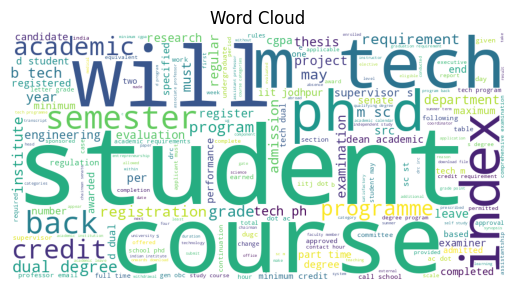

In [13]:
# ===============================
# STEP 5: WORD CLOUD
# ===============================

combined_text = " ".join(token_stream)

wc = WordCloud(width=900, height=450, background_color='white')
wc_image = wc.generate(combined_text)

plt.imshow(wc_image)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [14]:
# ===============================
# STEP 6: PREPARE SENTENCES
# ===============================

def sequence_chunker(tokens, chunk_size=20):
    """
    Break token list into smaller chunks.
    Word2Vec expects list of sentences.
    """
    return [tokens[i:i+chunk_size] for i in range(0, len(tokens), chunk_size)]

training_sequences = sequence_chunker(token_stream)

In [15]:
# ===============================
# STEP 7: TRAIN WORD2VEC MODELS
# ===============================

# CBOW Model
cbow_model = Word2Vec(
    sentences=training_sequences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=0,
    negative=5,
    epochs=10
)

# Skip-gram Model
skip_model = Word2Vec(
    sentences=training_sequences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    negative=5,
    epochs=10
)

In [16]:
# ===============================
# STEP 8: SEMANTIC ANALYSIS
# ===============================

test_words = ["research", "student", "phd", "exam"]

for word in test_words:
    if word in cbow_model.wv:
        print(f"\nNearest words for {word}:")
        print(cbow_model.wv.most_similar(word, topn=5))
    else:
        print(f"{word} not found in vocabulary")


Nearest words for research:
[('committee', 0.9995367527008057), ('two', 0.9995266199111938), ('through', 0.9995188117027283), ('one', 0.9994844198226929), ('may', 0.9994813799858093)]

Nearest words for student:
[('a', 0.9992541670799255), ('who', 0.999189555644989), ('can', 0.9991828203201294), ('is', 0.999181866645813), ('after', 0.9991315007209778)]

Nearest words for phd:
[('email', 0.9984416961669922), ('professor', 0.9976605176925659), ('at', 0.9974109530448914), ('indian', 0.9966496229171753), ('iitj', 0.9965865612030029)]
exam not found in vocabulary


In [17]:
# ===============================
# STEP 9: ANALOGY TEST
# ===============================

try:
    analogy = skip_model.wv.most_similar(
        positive=["pg", "btech"],
        negative=["ug"]
    )
    print("UG : BTech :: PG : ?", analogy)
except:
    print("Analogy words missing")

Analogy words missing


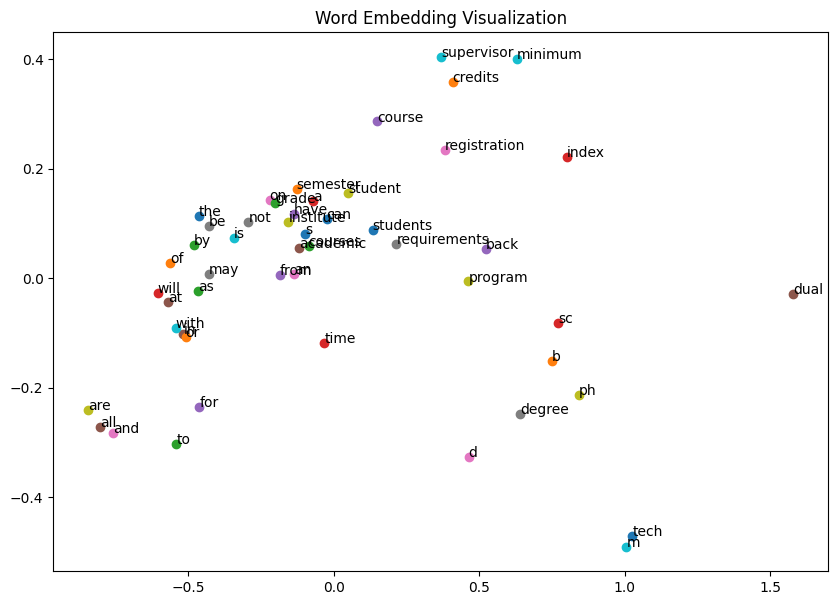

In [18]:
# ===============================
# STEP 10: PCA VISUALIZATION
# ===============================

words = list(cbow_model.wv.index_to_key)[:50]
vectors = [cbow_model.wv[w] for w in words]

pca = PCA(n_components=2)
points = pca.fit_transform(vectors)

plt.figure(figsize=(10,7))

for i, word in enumerate(words):
    plt.scatter(points[i][0], points[i][1])
    plt.text(points[i][0], points[i][1], word)

plt.title("Word Embedding Visualization")
plt.show()

In [21]:
model = Word2Vec(sentences=[token_stream], vector_size=100, window=5, min_count=1)

word = "research"

vector = model.wv[word]

print(word, "-", ", ".join([str(round(v, 4)) for v in vector]))

research - -0.1904, 0.2044, -0.0838, 0.2143, 0.2133, -0.4864, -0.037, 0.6896, -0.1914, -0.1572, 0.0945, -0.3551, -0.0269, 0.1205, 0.0909, -0.2165, 0.063, -0.3199, -0.1256, -0.6573, 0.0871, 0.1388, 0.3327, -0.1592, -0.0978, -0.0322, -0.2062, 0.04, -0.4361, 0.1045, 0.4084, -0.0576, 0.3945, -0.1742, -0.2231, 0.3784, 0.1638, -0.2286, -0.0791, -0.4044, 0.0799, -0.4189, -0.2035, 0.0343, 0.2969, -0.129, -0.333, -0.1594, 0.2368, 0.035, 0.1967, -0.3427, 0.0346, -0.1606, -0.1047, 0.0844, 0.4311, -0.0009, -0.2686, 0.302, -0.0534, -0.0543, 0.0409, -0.128, -0.2186, 0.4229, 0.0627, 0.3563, -0.6822, 0.4773, -0.1771, 0.073, 0.3665, 0.1063, 0.2226, 0.0897, 0.0859, 0.0695, -0.3489, -0.0573, -0.3416, 0.036, -0.4495, 0.4485, -0.2035, -0.1941, 0.1542, 0.3224, 0.3762, 0.0655, 0.54, 0.1895, 0.0257, 0.1604, 0.4423, 0.2687, 0.1625, -0.1487, 0.0117, 0.0113


In [29]:
from nltk.corpus import stopwords
from collections import Counter
import nltk

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

# remove stopwords + small words
filtered_tokens = [w for w in token_stream if w not in stop_words and len(w) > 2]

# count frequency
word_counts = Counter(filtered_tokens)

# top 10 words
top_10 = word_counts.most_common(10)

# print in required format
output = ", ".join([f"{word}, {freq}" for word, freq in top_10])

print(output)

student, 219, tech, 187, course, 148, academic, 135, degree, 121, students, 118, semester, 114, back, 112, index, 112, requirements, 105


In [28]:
print(list(model.wv.index_to_key)[:50])

['the', 'of', 'to', 'a', 'for', 'in', 'and', 'be', 'student', 'm', 'tech', 'or', 'by', 'will', 'course', 'academic', 'd', 'degree', 'ph', 'is', 'students', 'semester', 'as', 'index', 'back', 'at', 'on', 'requirements', 'program', 'with', 's', 'credits', 'courses', 'sc', 'from', 'all', 'an', 'may', 'institute', 'minimum', 'can', 'b', 'grade', 'time', 'have', 'dual', 'registration', 'not', 'are', 'supervisor']
